In [2]:
import numpy as np
from h5py import File

import csiborgtools
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM

%matplotlib inline
%load_ext autoreload
%autoreload 2

### Read in the FP data

In [ ]:
SPEED_OF_LIGHT = 299_792.458
cosmo = FlatLambdaCDM(H0=100, Om0=0.3)


with File("/mnt/extraspace/rstiskalek/catalogs/PV/CF4/SDSS-FP.hdf5", 'r') as f:
    # print(f.keys())
    # for key in f.keys():
    #     print(key)

    rdev = f["rad"][...]
    erdev = f["erad"][...]
    boa = f["boa"][...]
    eboa = f["eboa"][...]
    sig = f["sig"][...]
    esig = f["esig"][...]
    plate = f["plate"][...]

    rmag = f["rmag"][...]
    ermag = f["ermag"][...]

    zcmb = f["gczcmb"][...] / SPEED_OF_LIGHT

    Ar = f["Exr"][...]
    kr = f["kcr"][...]

    logIe_provided = f["i"][...]
    log_sig0_provided = f["s"][...]
    log_Re_provided = f["r"][...]# / 1000 # Convert from kpc / h to Mpc / h

    ei = f["ei"][...]
    es = f["es"][...]
    er = f["er"][...]

# Numerical constant
N = 45.07696701313217
Msun = 4.65

# Compute the effective angular radius from the de Vaucouleurs radius and
# the axis ratio and propagate the uncertainty.
theta_eff = rdev * np.sqrt(boa)
etheta_eff = theta_eff * np.sqrt((erdev / rdev)**2 + (eboa / (2 * boa))**2)

log_theta_eff = np.log10(theta_eff)
elog_theta_eff = etheta_eff / theta_eff / np.log(10)

# Compute the central velocity dispersion and propagate the uncertainty.
theta_aperture = np.ones_like(plate) * 1.5
theta_aperture[plate >= 3510] = 1.0

sig0 = sig * (theta_eff / 8 / theta_aperture)**(-0.04)
esig0 = sig0 * np.sqrt((0.0016 * etheta_eff**2) / (theta_aperture**2 * (theta_eff / theta_aperture)**2) + (1.0 * esig**2) / sig**2)

log_sig0 = np.log10(sig0)
elog_sig0 = esig0 / sig0 / np.log(10)



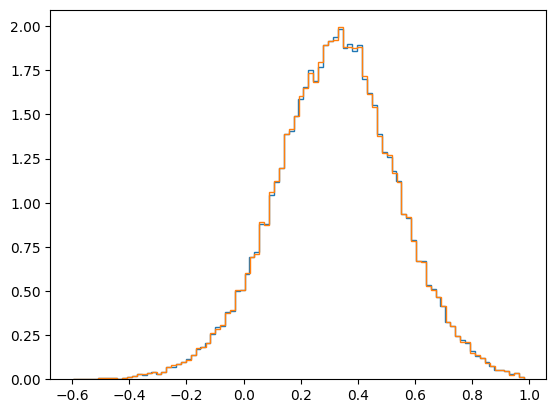

In [21]:
plt.figure()
plt.hist(np.log10(cosmo.angular_diameter_distance(zcmb).value * 1000 * theta_eff * 4.84814e-6), bins="auto", histtype="step", density=1)
plt.hist(log_Re_provided, bins="auto", histtype="step", density=1)

plt.show()



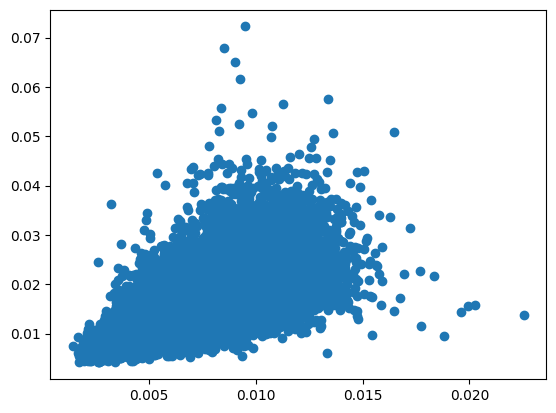

In [4]:
plt.figure()
plt.scatter(er, es)
plt.show()

### Fundamental plane: predict apparent magnitude

In [173]:
def get_effective_surface_brightness(mr, z, theta_eff, kr, Ar):
    return mr + 0.85 * z + 2.5 * np.log10(2 * np.pi * theta_eff**2) -2.5 * np.log10((1 + z)**4) - kr - Ar


def get_log_Ie(mu_e):
    return 0.4 * Msun - 0.4 * mu_e + 2 * np.log10(206265 / 10)


def get_log_Re(a, b, c, log_sig0, log_Ie):
    return a * log_sig0 + b * log_Ie + c

# def mr_from_fp(a, b, c, ):
#     z = zcmb
#     da = cosmo.angular_diameter_distance(z).value * 1000
#     mr = (2.5 / b) * (c - np.log10(da) + a * log_sig0 + b * np.log10((1 + z)**4) - (1 + 2 * b) * log_theta_eff)
#     mr += N + Ar + kr + Msun - 0.85 * z
#     return mr


# def mr_from_fp(a, b, c):

#     z = zcmb
#     da = cosmo.angular_diameter_distance(z).value

#     logIe = log_theta_eff + np.log10(da) - (a * log_sig0 + c) / b
    
#     return (Msun + 5 * np.log10(206_625 / 10)
#             - 2.5 * (logIe + np.log10(2 * np.pi * theta_eff**2) - np.log10((1 + z)**4))
#             - 0.85 * z + kr + Ar)
    
def mr_from_fp(z, a, b, c):
    da = cosmo.angular_diameter_distance(z).value

    K = 0.4 * (Msun - 0.85 * z + kr + Ar)

    log_Re = log_theta_eff + np.log10(da) + 3 + np.log10(np.pi) - np.log10(648_000)

    mr = K - np.log10(2 * np.pi) - 2 * log_theta_eff
    mr += 4 * (np.log10(1 + z))  # noqa
    mr += 2 * np.log10(64_800 / np.pi) - (log_Re - a * log_sig0 - c) / b
    mr /= 0.4
    return mr


In [201]:
print(a, b, c)

1.274 -0.841 -0.33


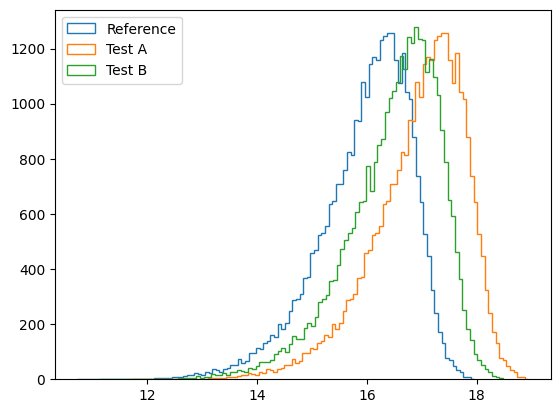

In [185]:
z = zcmb


plt.figure()
plt.hist(mr_from_fp(z, a, b, c), bins="auto", histtype="step", label="Reference")

plt.hist(mr_from_fp(z, a, b, 2 * c), bins="auto", histtype="step", label="Test A")

plt.hist(mr_from_fp(z / 0.5, a, b,  0.5 * c), bins="auto", histtype="step", label="Test B")


plt.legend()


plt.show()

### 3D Gaussian in redshift-space

In [ ]:
from jax import numpy as jnp

class GaussianFP:

    def __init__(self, ztot, log_sig0, log_Ie, e_log_sig0, e_log_Ie):
        self.ztot = jnp.asarray(ztot)
        self.log_da = jnp.log10(cosmo.angular_diameter_distance(ztot).value)

        self.log_sig0 = jnp.asarray(log_sig0)
        self.log_Ie = jnp.asarray(log_Ie)
        self.e_log_sig0 = jnp.asarray(e_log_sig0)
        self.e_log_Ie = jnp.asarray(e_log_Ie)
    
    
    def __call__(self):


return a * log_sig0 + b * log_Ie + 

### Flow model

In [328]:
from jax import numpy as jnp

from numpyro.distributions import Uniform, Normal, TruncatedNormal
from numpyro import factor, sample, plate


class FP_FlowModel:
    
    def __init__(self, ztot, theta_eff, sig0, mr, e_mr, kr, Ar):
        self.ztot = jnp.asarray(ztot)
        self.log_theta_eff = jnp.log10(theta_eff)
        self.log_sig0 = jnp.log10(sig0)
        self.mr = jnp.asarray(mr)
        self.e_mr = jnp.asarray(e_mr)

        self.kr = jnp.asarray(kr)
        self.Ar = jnp.asarray(Ar)

        self.Ngal = len(mr)

        print(f"We have {self.Ngal} galaxies up to z = {self.ztot.max()}")

    def predict_mr(self, r, a, b, c):
        """
        Predict apparent magnitude from comoving distance, assuming Hubble law
        and that angular diamaeter distance is equal to comoving distance.
        """
        Msun = 4.65
        da = r

        z = 100 * r / SPEED_OF_LIGHT

        K = 0.4 * (Msun - 0.85 * z + self.kr + self.Ar)

        log_Re = self.log_theta_eff + jnp.log10(da) + 3 + jnp.log10(np.pi) - jnp.log10(648_000)

        mr = K - jnp.log10(2 * np.pi) - 2 * self.log_theta_eff
        mr += 4 * (jnp.log10(1 + z))  # noqa
        mr += 2 * jnp.log10(64_800 / np.pi) - (log_Re - a * self.log_sig0 - c) / b
        mr /= 0.4
        return mr
    
    def __call__(self):
        rmin = 0.1
        rmax = 250

        # with plate("r_plate", self.Ngal):
        #     r = sample("r", Uniform(rmin, rmax))

        r = self.ztot * SPEED_OF_LIGHT / 100

        a = sample("a", Uniform(-2, 2))
        b = sample("b", Uniform(-2, 2))
        c = sample("c", Uniform(-2, 2))
        # a = 1.274
        # # b = -0.841
        # c = -0.33

        mr = self.predict_mr(r, a, b, c)
        # mr = jnp.clip(mr, 0, 17)

        sigma_int = 0.05
        err = jnp.sqrt(self.e_mr**2 + sigma_int**2)

        with plate("mr_plate_likelihood", self.Ngal):
            sample("mr_ll", Normal(mr, err), obs=self.mr)


In [329]:
from numpyro.infer import MCMC, NUTS
from jax import random
from numpyro.infer import init_to_median, init_to_feasible, init_to_sample

m = zcmb < 0.05
model = FP_FlowModel(zcmb[m], theta_eff[m], sig0[m], rmag[m], ermag[m], kr[m], Ar[m])


kernel = NUTS(model, init_strategy=init_to_median(num_samples=3000))
# kernel = NUTS(model, init_strategy=init_to_feasible())
mcmc = MCMC(kernel, num_warmup=1000, num_samples=1000, num_chains=1)
mcmc.run(random.PRNGKey(0), )
samples = mcmc.get_samples()
mcmc.print_summary()

We have 7447 galaxies up to z = 0.04999125003814697


sample: 100%|██████████| 2000/2000 [00:03<00:00, 531.15it/s, 51 steps of size 2.09e-02. acc. prob=0.93] 


                mean       std    median      5.0%     95.0%     n_eff     r_hat
         a      1.11      0.00      1.11      1.10      1.11    253.07      1.00
         b     -0.94      0.00     -0.94     -0.94     -0.94    322.67      1.00
         c      0.30      0.00      0.30      0.30      0.31    255.68      1.00

Number of divergences: 0


In [324]:
r = model.ztot * SPEED_OF_LIGHT / 100

# mr = model.predict_mr(r, samples["a"].mean(), samples["b"].mean(), samples["c"].mean())
mr = model.predict_mr(r, 1.274, -0.841, samples["c"].mean())

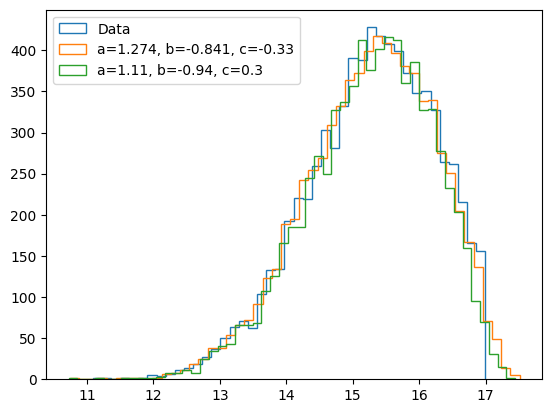

In [332]:
plt.figure()
plt.hist(model.mr, bins="auto", histtype="step", label="Data")
plt.hist(model.predict_mr(model.ztot * SPEED_OF_LIGHT / 100, 1.274, -0.841, -0.33), bins="auto", histtype="step",
         label=r"a=1.274, b=-0.841, c=-0.33")
plt.hist(model.predict_mr(model.ztot * SPEED_OF_LIGHT / 100, 1.11, -0.94, 0.3), bins="auto", histtype="step",
         label=r"a=1.11, b=-0.94, c=0.3")
plt.legend()
plt.savefig("../../mr_dist.png", dpi=450)

plt.show()

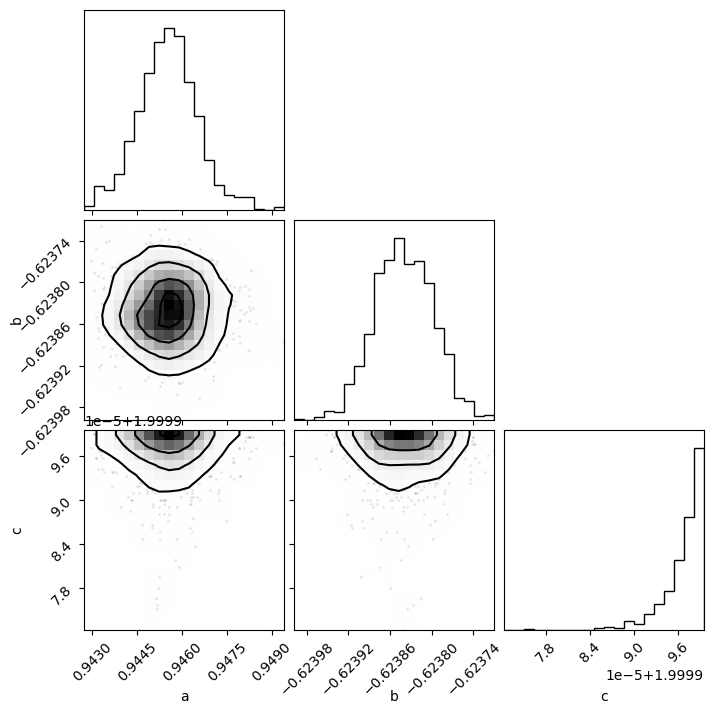

In [311]:
from corner import corner
data = np.vstack([samples["a"], samples["b"], samples["c"]]).T
fig = corner(data, labels=["a", "b", "c"], smooth=1)
# data = np.vstack([samples["b"], samples["c"]]).T
# fig = corner(data, labels=["b", "c"], smooth=1)
fig.show()

In [161]:
# These options seem to match the provided SDSS data
a = 1.274
b = -0.841
# c = -0.655
c = -0.33



In [117]:
# from scipy.optimize import minimize

# def chi2(c):
#     return np.sum((get_log_Re(a, b, c, log_sig0_provided, logIe_provided) - log_Re_provided)**2)


# minimize(chi2, -0.4, method="Nelder-Mead")

In [ ]:
# mr_from_fp(a, b, c)

array([55.7180197 , 53.60573159, 55.4623489 , ..., 57.300126  ,
       57.89071763, 57.16040646])

In [90]:
log_Re_provided

array([0.55667, 0.15331, 0.57642, ..., 0.17439, 0.17133, 0.50851])

In [88]:
mue = get_effective_surface_brightness(rmag, zcmb, theta_eff, kr, Ar)
get_log_Ie(mue)

array([2.65904839, 2.69608669, 2.63782364, ..., 2.76985102, 2.43549547,
       2.5303866 ])

In [ ]:


mr_from_fp(a, b, c)

array([51.96507009, 49.72820196, 51.73005005, ..., 53.60929603,
       53.6229478 , 53.28265   ])

In [49]:
rmag

array([14.457, 12.855, 14.262, ..., 16.783, 16.777, 16.019])